# Quantum Entanglement — Bell State

This experiment demonstrates the creation and measurement of a two-qubit Bell state using Qiskit.

In [2]:
import qiskit

print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.5.2


In [3]:
from qiskit import QuantumCircuit

# Create a 2-qubit quantum circuit
bell = QuantumCircuit(2)

print(bell)

     
q_0: 
     
q_1: 
     


## Creating the Bell State

The Bell state is created by first applying a Hadamard gate to qubit 0,
followed by a CNOT gate with qubit 0 as the control and qubit 1 as the target.

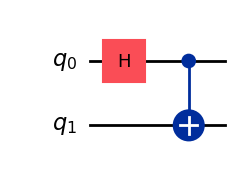

In [4]:
# Create the Bell state
bell.h(0)
bell.cx(0, 1)

# print(bell)
bell.draw("mpl")

## Theoretical State

The resulting circuit produces the Bell state

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
$$

This means that the ideal probabilities of measuring `00` and `11` are
50% each, while `01` and `10` have zero probability.

In [5]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(bell)

print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [6]:
probabilities = state.probabilities_dict()

print(probabilities)

{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


## Measurement and Simulation

The Bell state is measured over 1024 shots using Qiskit's
StatevectorSampler. The measured results are compared with the
theoretical 50/50 probability distribution.

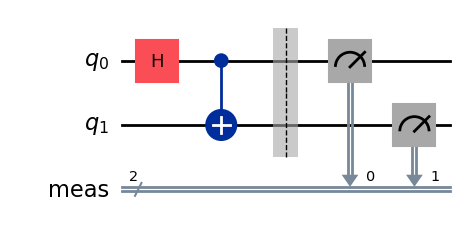

In [8]:
from qiskit.primitives import StatevectorSampler

# Create a copy of the Bell circuit for measurement
measured_bell = bell.copy()
measured_bell.measure_all()

measured_bell.draw("mpl")

In [9]:
sampler = StatevectorSampler()

result = sampler.run([measured_bell], shots=1024).result()

counts = result[0].data.meas.get_counts()

print(counts)

{'11': 511, '00': 513}


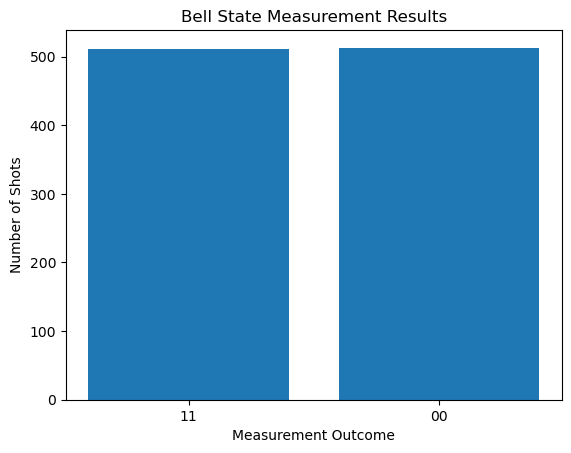

In [10]:
import matplotlib.pyplot as plt

states = list(counts.keys())
values = list(counts.values())

plt.bar(states, values)

plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Bell State Measurement Results")

plt.show()

## Conclusion

The ideal simulation produced only the correlated outcomes `00` and `11`,
with approximately equal probabilities. This agrees with the theoretical
Bell state

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

The results demonstrate the characteristic correlations of a two-qubit
Bell state.

## Running on Real IBM Quantum Hardware

The Bell-state circuit is executed on a real IBM Quantum processor
to observe the effect of hardware noise on the ideal entangled state.

In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Connect to IBM Quantum using the saved credentials
service = QiskitRuntimeService()

# Select the least-busy operational real QPU
backend = service.least_busy(
    operational=True,
    simulator=False
)

print("Selected backend:", backend.name)

Selected backend: ibm_fez


In [13]:
import sys
import importlib.metadata as metadata

print("Python:", sys.executable)
print("Qiskit:", metadata.version("qiskit"))
print("Qiskit IBM Runtime:", metadata.version("qiskit-ibm-runtime"))

Python: D:\Anaconda\python.exe
Qiskit: 2.5.2
Qiskit IBM Runtime: 0.49.0


In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService

print("IBM Quantum Runtime imported successfully!")

IBM Quantum Runtime imported successfully!


## Preparing the Circuit for Real Hardware

Before execution on a real quantum processor, the Bell-state circuit
must be transpiled into instructions supported by the selected IBM
Quantum hardware.

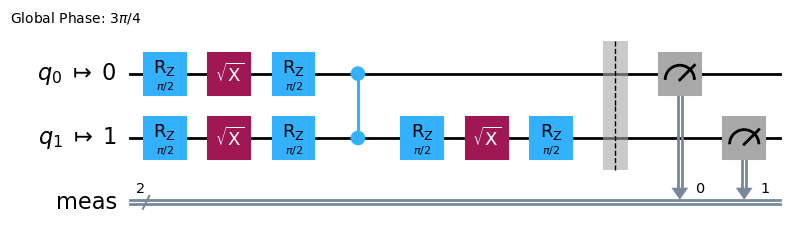

In [15]:
from qiskit.transpiler import generate_preset_pass_manager

# Transpile the measured Bell circuit for the selected hardware
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_bell = pass_manager.run(measured_bell)

# print(isa_bell)
isa_bell.draw("mpl")

## Running the Bell State on Real IBM Quantum Hardware

The transpiled Bell-state circuit is now submitted to the selected
IBM Quantum processor. The measured results will be compared with
the ideal simulation to observe the effect of real hardware noise.

In [13]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Create a Sampler for the selected IBM Quantum backend
sampler = Sampler(mode=backend)

# Run the transpiled Bell-state circuit on real hardware
job = sampler.run([isa_bell], shots=1024)

print("Job submitted successfully!")
print("Job ID:", job.job_id())

Job submitted successfully!
Job ID: daooqc02fm4c73f5op0g


In [14]:
# Wait for the real hardware job to complete and retrieve the result
result_hardware = job.result()

# Extract measurement counts
hardware_counts = result_hardware[0].data.meas.get_counts()

print("Real IBM Quantum hardware results:")
print(hardware_counts)

Real IBM Quantum hardware results:
{'11': 497, '00': 502, '10': 18, '01': 7}


## Real Hardware Results

The Bell-state circuit was executed on a real IBM Quantum processor
using 1024 shots. Unlike the ideal simulation, the hardware results
contain a small number of `01` and `10` outcomes due to noise and
imperfections in the physical quantum processor.

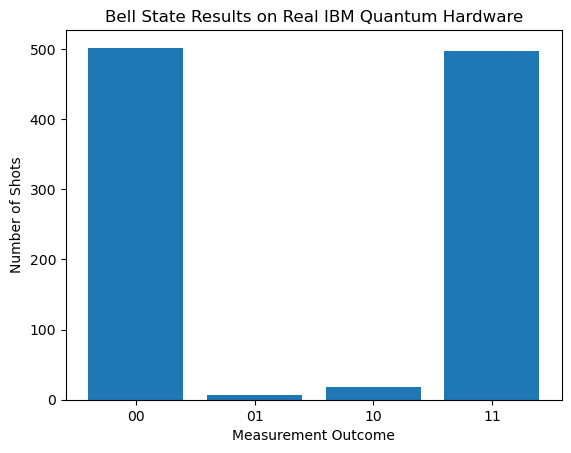

In [15]:
import matplotlib.pyplot as plt

states = ["00", "01", "10", "11"]
values = [hardware_counts.get(state, 0) for state in states]

plt.bar(states, values)

plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Bell State Results on Real IBM Quantum Hardware")

plt.show()

## Ideal Simulation vs Real Hardware

The ideal Bell state produces only the correlated outcomes `00` and `11`,
with equal probabilities of 50% each. On real IBM Quantum hardware,
the same outcomes remain dominant, but a small number of `01` and `10`
measurements appear due to hardware noise and imperfections.

For 1024 hardware shots, the measured distribution was:

- `00`: 502 shots (49.02%)
- `11`: 497 shots (48.54%)
- `10`: 18 shots (1.76%)
- `01`: 7 shots (0.68%)

Thus, the correlated outcomes `00` and `11` occurred in 999 out of
1024 shots, corresponding to approximately 97.56% of the measurements.

## Comparison of Ideal and Real Hardware Results

The following comparison shows the difference between the ideal Bell-state
distribution and the distribution obtained from real quantum hardware.

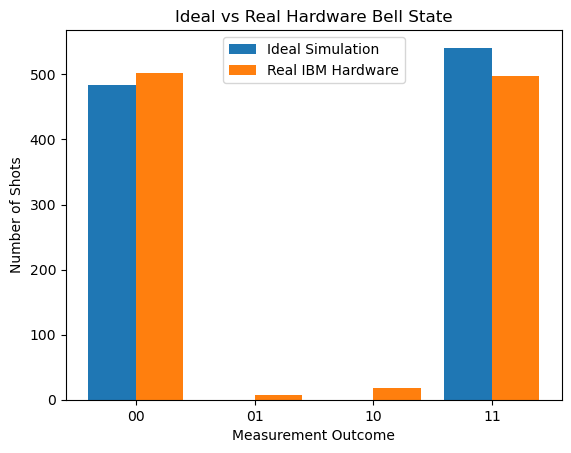

In [17]:
import matplotlib.pyplot as plt

states = ["00", "01", "10", "11"]

ideal_counts = [483, 0, 0, 541]
hardware_counts_ordered = [
    hardware_counts.get(state, 0) for state in states
]

x = range(len(states))

plt.bar(x, ideal_counts, width=0.4, label="Ideal Simulation")
plt.bar(
    [i + 0.4 for i in x],
    hardware_counts_ordered,
    width=0.4,
    label="Real IBM Hardware"
)

plt.xticks([i + 0.2 for i in x], states)
plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Ideal vs Real Hardware Bell State")
plt.legend()

plt.show()

## Experiment Summary

- **Quantum state:** Bell state $|\Phi^+\rangle$
- **Simulation shots:** 1024
- **Hardware:** IBM Quantum `ibm_marrakesh`
- **Hardware shots:** 1024
- **Ideal correlated outcomes:** `00`, `11`
- **Hardware correlated outcomes:** 999/1024 (97.56%)

## Conclusion

The Bell state was successfully prepared and measured using Qiskit.

The ideal statevector simulation produced the expected correlated outcomes
`00` and `11` with equal probability. The 1024-shot ideal simulation also
produced only `00` and `11`, with small statistical variation around the
theoretical 50/50 distribution.

The Bell-state circuit was then transpiled and executed on the real
IBM Quantum processor `ibm_marrakesh`. The hardware produced `00` and
`11` in 999 out of 1024 measurements (97.56%), while a small number of
`01` and `10` outcomes were observed.

These additional outcomes demonstrate the effect of noise and
imperfections in real quantum hardware and provide a practical comparison
between ideal quantum simulation and execution on a real quantum processor.